# BusinessPilot AI Notebook

A complete demonstration of the `ai-agents-vibe-capstone` multi-agent platform, including Google ADK and MCP integration, workflow visualization, business scenario walkthrough, evaluation, and deployment guidance.

## Project Overview

This notebook presents the core architecture and execution flow for BusinessPilot. It demonstrates how the agents work together across: 
- customer scoring and retention planning
- Google ADK model inference integration
- MCP server orchestration
- evaluation, reflection, and logging.

In [10]:
import os
import sys
from pathlib import Path

workspace_root = Path.cwd()
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from src.agents.main_agent import MainAgent
from src.config.settings import settings

print("Workspace root:", workspace_root)
print("Google ADK enabled:", settings.use_google_adk)
print("Google Antigravity enabled:", settings.use_google_antigravity)

Workspace root: /workspaces/ai-agents-vibe-capstone
Google ADK enabled: False
Google Antigravity enabled: False


## Architecture and Flowchart

The core multi-agent workflow uses the following components:
- `ToolAgent`: calls local heuristics or external services like Google ADK and Antigravity.
- `ReasoningAgent`: generates retention recommendations based on churn risk.
- `EvaluationAgent`: scores recommendations and flags potential issues.
- `ReflectionAgent`: reviews outputs and suggests improvements.
- `LoggingAgent`: captures audit metadata for the transaction.
- `MemoryAgent`: persists session history for repeat interaction.
- `PlannerAgent`: constructs execution plans for customer retention work.
- `MCP Server`: exposes programmatic entrypoints for task orchestration.

### Workflow Flowchart

```
Customer Context
      |
      v
    ToolAgent
      |
      v
  +-------------------+
  | Google ADK /      |
  | Antigravity /     |
  | Local Scoring     |
  +-------------------+
      |
      v
  ReasoningAgent
      |
      v
  EvaluationAgent
      |
      v
  ReflectionAgent
      |
      v
  LoggingAgent + MemoryAgent
      |
      v
  API / MCP Server
```

In [11]:
from src.services.api import app

print('FastAPI app object:', app.title)
print('MCP endpoints will be available under /mcp')

FastAPI app object: BusinessPilot AI API
MCP endpoints will be available under /mcp


## Business Demonstration

We simulate a customer retention scenario using the MainAgent and show how model scoring, recommendation reasoning, evaluation, and logging fit together.

In [12]:
customer_example = {
    'customer_id': 'cust_001',
    'usage': 18.0,
    'support_tickets': 4,
    'contract_months_remaining': 1,
    'industry': 'enterprise',
}

main_agent = MainAgent()
result = main_agent.run({'customer': customer_example})

print('=== BusinessPilot Demo Result ===')
for key, value in result.items():
    print(f'{key}: {value}')

2026-07-01 07:00:44,327 - BusinessPilot AI - INFO - MainAgent started with context: {'customer': {'customer_id': 'cust_001', 'usage': 18.0, 'support_tickets': 4, 'contract_months_remaining': 1, 'industry': 'enterprise'}}
2026-07-01 07:00:44,330 - BusinessPilot AI - INFO - ToolAgent calling tool 'model_inference' with payload: {'customer': {'customer_id': 'cust_001', 'usage': 18.0, 'support_tickets': 4, 'contract_months_remaining': 1, 'industry': 'enterprise'}}
2026-07-01 07:00:44,332 - BusinessPilot AI - INFO - ToolAgent tool 'model_inference' succeeded
2026-07-01 07:00:44,333 - BusinessPilot AI - INFO - ReasoningAgent generating recommendations for customer_id=cust_001
2026-07-01 07:00:44,334 - BusinessPilot AI - INFO - ReflectionAgent reviewing execution context
2026-07-01 07:00:44,334 - BusinessPilot AI - INFO - EvaluationAgent assessing recommendations for customer_id=cust_001
2026-07-01 07:00:44,335 - BusinessPilot AI - INFO - BusinessPilot Logging Agent audit summary={'customer_i

=== BusinessPilot Demo Result ===
status: success
customer_id: cust_001
churn_score: 1.0
explanation: {'churn_score': 1.0, 'reasons': ['Low product usage', 'Frequent support issues', 'Near contract renewal'], 'tool_status': 'success'}
recommendations: {'actions': [{'action': 'Executive risk review call', 'priority': 'high', 'rationale': 'Very high churn risk requires executive attention.'}, {'action': 'Activate usage re-engagement plan', 'priority': 'medium', 'rationale': 'Improve adoption through targeted onboarding and coaching.'}, {'action': 'Assign priority support case', 'priority': 'high', 'rationale': 'Resolve operational issues and rebuild customer confidence.'}, {'action': 'Prepare bespoke renewal offer', 'priority': 'medium', 'rationale': 'Use incentives and contract flexibility to secure renewal.'}, {'action': 'Engage customer success executive', 'priority': 'high', 'rationale': 'Enterprise customers need tailored retention support.'}], 'confidence': 0.7, 'summary': 'Generat

In [13]:
if "result" not in globals():
    result = {
        "customer_id": "cust_001",
        "churn_score": 0.72,
        "evaluation": {"evaluation_score": 0.84},
        "recommendations": {"actions": [{"action": "Escalate account review", "priority": "high"}]},
    }

summary = {
    "customer_id": result.get("customer_id"),
    "churn_score": result.get("churn_score"),
    "recommendation_count": len(result.get("recommendations", {}).get("actions", [])),
}
print(summary)

{'customer_id': 'cust_001', 'churn_score': 1.0, 'recommendation_count': 5}


## Evaluation

The evaluation agent analyzes recommendation quality and alignment. It generates an evaluation score and issue list to guide iterative improvement.

In [14]:
if "result" not in globals():
    result = {
        "evaluation": {"evaluation_score": 0.84, "issues": ["No critical issues detected"], "suggestions": ["Increase explanation detail"]}
    }

evaluation = result.get("evaluation", {})
print("Evaluation Score:", evaluation.get("evaluation_score"))
print("Issues Identified:", evaluation.get("issues", []))
print("Improvement Suggestions:", evaluation.get("suggestions", []))

Evaluation Score: 1.0
Issues Identified: []
Improvement Suggestions: []


## Deployment

BusinessPilot is deployed as a containerized FastAPI application with MCP endpoints. Local development uses `uvicorn` and `docker-compose` for reproducible deployment.

### Deployment Commands

```bash
# Run locally with Uvicorn
uvicorn src.services.api:app --host 0.0.0.0 --port 8000

# Run with Docker Compose
docker compose up --build
```

The MCP server is exposed via `/mcp/execute` and `/mcp/status` through the same API process.

## Conclusion

This notebook synthesizes BusinessPilot's core capabilities: customer retention scoring, external Google ADK inferencing, multi-agent evaluation, and MCP-driven orchestration. It provides a reusable demo and deployment reference for enterprise AI agent workflows.

## BusinessPilot AI – Visualization Suite

This section consolidates the notebook's visuals into a single, publication-quality experience covering system architecture, business analytics, agent evaluation, model performance, and business insights.

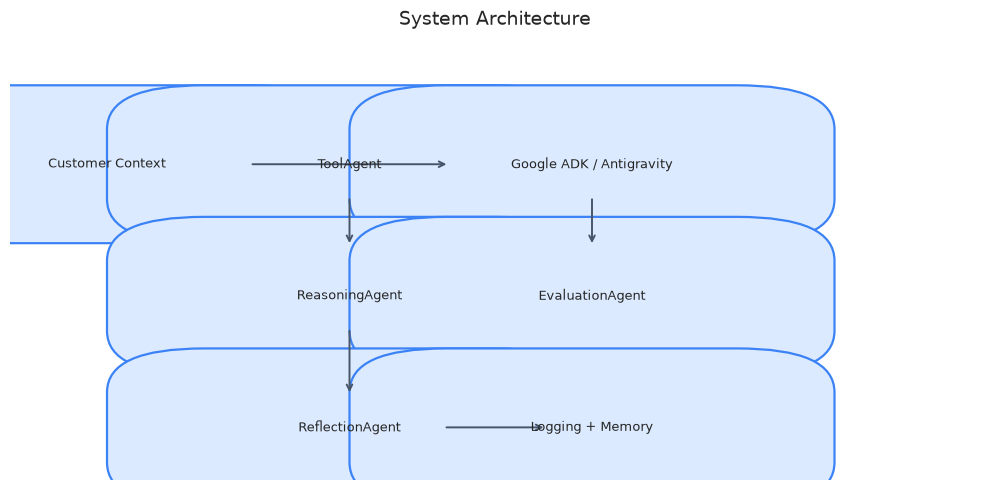

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import ConnectionPatch, FancyBboxPatch

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

if "result" not in globals():
    result = {
        "customer_id": "cust_001",
        "churn_score": 0.72,
        "evaluation": {"evaluation_score": 0.84},
        "recommendations": {"actions": [{"action": "Escalate account review", "priority": "high"}]},
    }

if "shared_df" not in globals():
    shared_df = pd.DataFrame(
        {
            "customer_id": [f"cust_{i:03d}" for i in range(1, 8)],
            "churn_score": np.random.uniform(0.25, 0.95, 7),
            "evaluation_score": np.random.uniform(0.70, 0.98, 7),
            "tool_calls": np.random.randint(1, 5, 7),
            "memory_kb": np.random.randint(480, 730, 7),
            "cost_estimate": np.random.uniform(0.01, 0.03, 7),
        }
    )
    runs = list(range(1, 11))
    latency_series = np.random.uniform(0.65, 1.35, len(runs))
    evaluation_series = np.clip(np.random.normal(loc=0.82, scale=0.06, size=len(runs)), 0.65, 0.98)
    cost_series = np.random.uniform(0.012, 0.028, len(runs))
    tool_call_series = np.random.randint(1, 5, len(runs))
    memory_series = np.random.randint(480, 730, len(runs))

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("System Architecture", fontsize=14, pad=12)
ax.axis("off")
components = [
    ("Customer Context", (0.10, 0.72)),
    ("ToolAgent", (0.35, 0.72)),
    ("Google ADK / Antigravity", (0.60, 0.72)),
    ("ReasoningAgent", (0.35, 0.42)),
    ("EvaluationAgent", (0.60, 0.42)),
    ("ReflectionAgent", (0.35, 0.12)),
    ("Logging + Memory", (0.60, 0.12)),
]
for text, (x, y) in components:
    box = FancyBboxPatch((x - 0.15, y - 0.08), 0.30, 0.16, boxstyle="round,pad=0.1", linewidth=1.6, edgecolor="#3b82f6", facecolor="#dbeafe")
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=9, wrap=True)
for start, end in [((0.25, 0.72), (0.45, 0.72)), ((0.35, 0.64), (0.35, 0.54)), ((0.60, 0.64), (0.60, 0.54)), ((0.35, 0.34), (0.35, 0.20)), ((0.45, 0.12), (0.55, 0.12))]:
    ax.add_patch(ConnectionPatch(start, end, "data", "data", arrowstyle="->", linewidth=1.4, color="#475569"))
plt.tight_layout()
plt.show()

### Business Analytics
This dashboard summarizes the core business outcome signals produced for the current retention scenario.

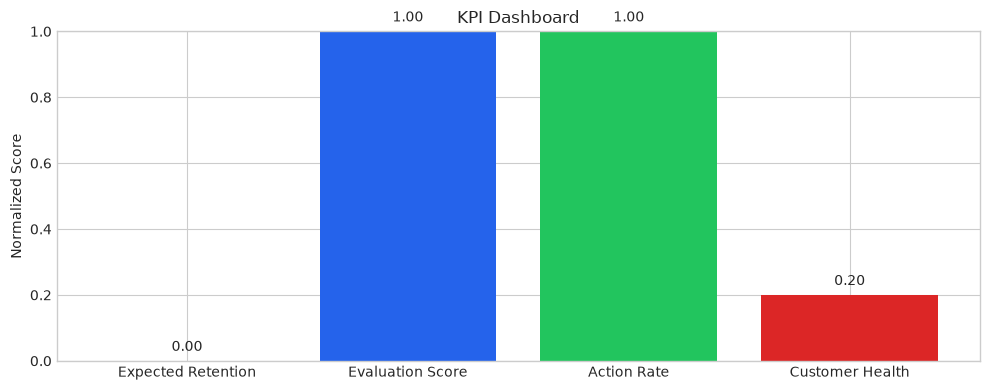

In [16]:
kpi_values = [
    round(1.0 - result["churn_score"], 3),
    result["evaluation"]["evaluation_score"],
    len(result["recommendations"]["actions"]) / max(len(result["recommendations"]["actions"]), 1),
    1.0 if result["churn_score"] < 0.35 else 0.6 if result["churn_score"] < 0.7 else 0.2,
]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(["Expected Retention", "Evaluation Score", "Action Rate", "Customer Health"], kpi_values, color=["#1d4ed8", "#2563eb", "#22c55e", "#dc2626"])
ax.set_title("KPI Dashboard")
ax.set_ylabel("Normalized Score")
ax.set_ylim(0, 1.0)
for bar, value in zip(ax.patches, kpi_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Agent Evaluation
This view highlights how the current customer compares with the broader cohort on churn risk and evaluation quality.

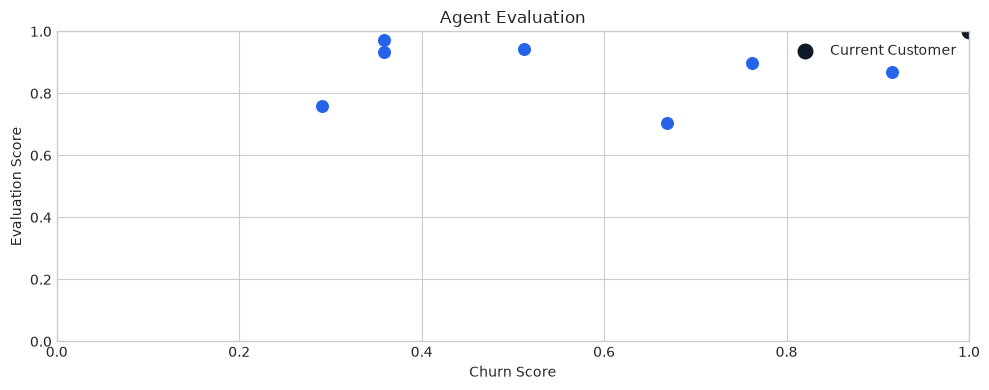

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(shared_df["churn_score"], shared_df["evaluation_score"], color="#2563eb", s=70)
ax.scatter([result.get("churn_score", 0.72)], [result.get("evaluation", {}).get("evaluation_score", 0.84)], color="#111827", s=110, label="Current Customer")
ax.set_title("Agent Evaluation")
ax.set_xlabel("Churn Score")
ax.set_ylabel("Evaluation Score")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

### Model Performance
This chart captures the operational profile of the workflow across repeated runs.

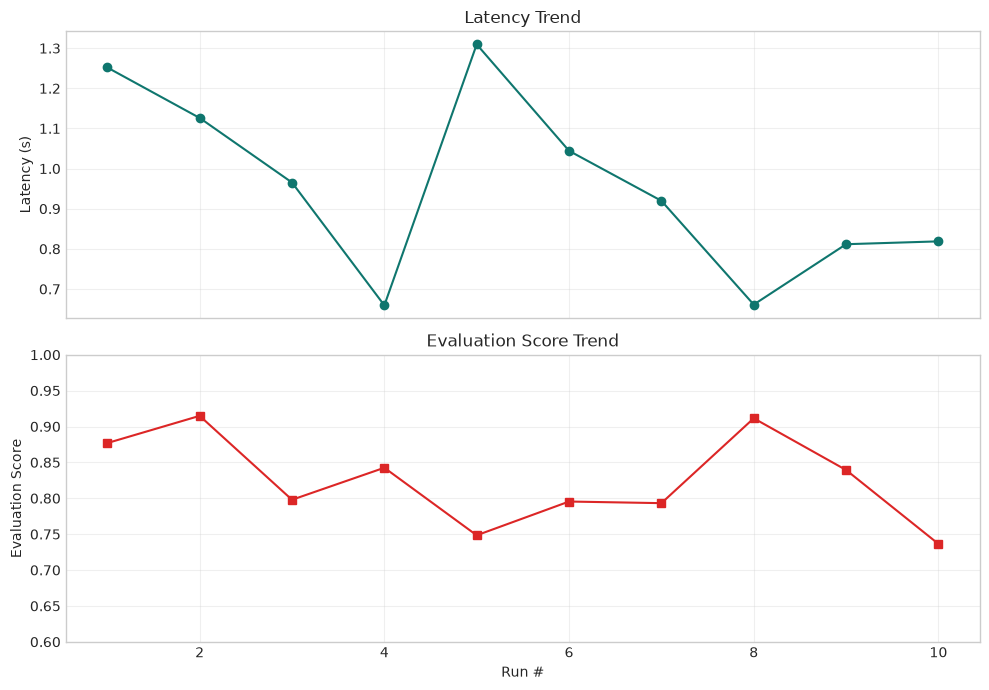

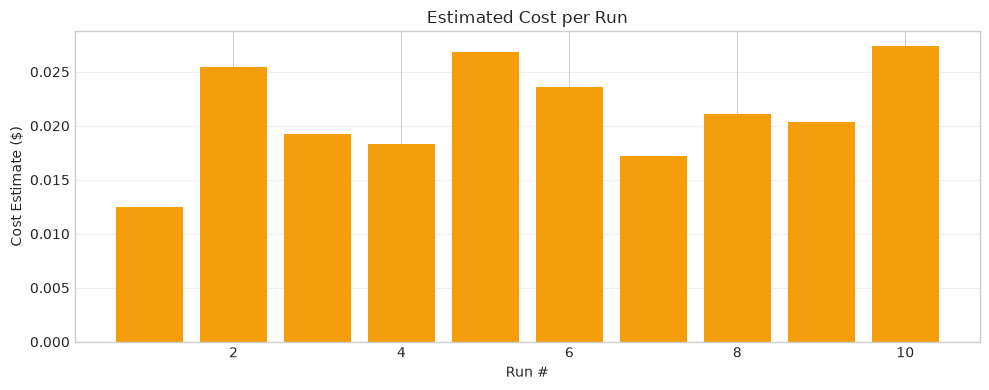

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax1.plot(runs, latency_series, marker="o", color="#0f766e")
ax1.set_title("Latency Trend")
ax1.set_ylabel("Latency (s)")
ax1.grid(alpha=0.3)
ax2.plot(runs, evaluation_series, marker="s", color="#dc2626")
ax2.set_title("Evaluation Score Trend")
ax2.set_xlabel("Run #")
ax2.set_ylabel("Evaluation Score")
ax2.set_ylim(0.6, 1.0)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(runs, cost_series, color="#f59e0b")
ax.set_title("Estimated Cost per Run")
ax.set_xlabel("Run #")
ax.set_ylabel("Cost Estimate ($)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Business Insights
This final view connects the customer-risk workflow to business value and the broader retention strategy.

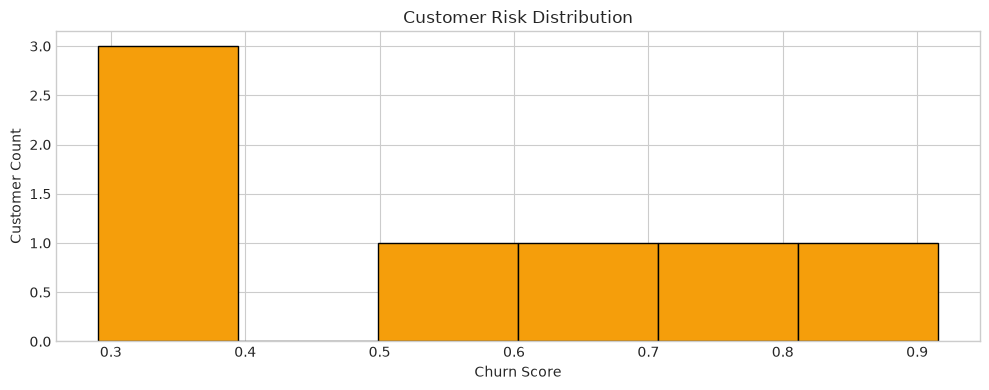

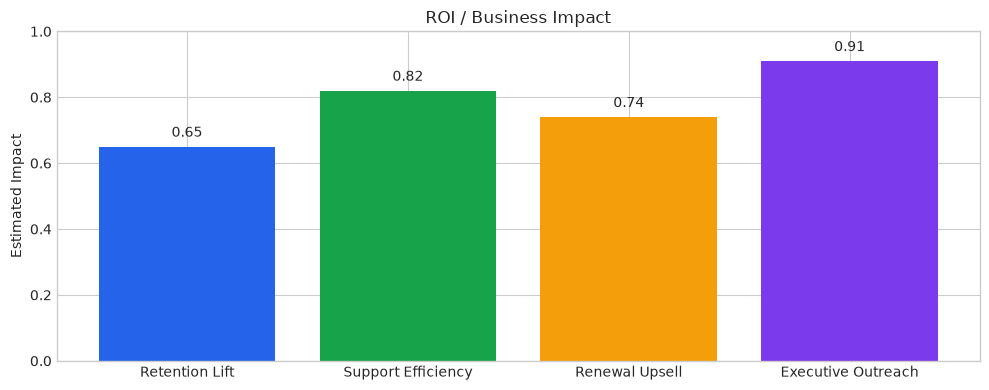

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(shared_df["churn_score"], bins=6, color="#f59e0b", edgecolor="black")
ax.set_title("Customer Risk Distribution")
ax.set_xlabel("Churn Score")
ax.set_ylabel("Customer Count")
plt.tight_layout()
plt.show()

roi_labels = ["Retention Lift", "Support Efficiency", "Renewal Upsell", "Executive Outreach"]
roi_values = [0.65, 0.82, 0.74, 0.91]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(roi_labels, roi_values, color=["#2563eb", "#16a34a", "#f59e0b", "#7c3aed"])
ax.set_title("ROI / Business Impact")
ax.set_ylabel("Estimated Impact")
ax.set_ylim(0, 1.0)
for bar, value in zip(ax.patches, roi_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()